In [4]:
import pandas as pd
df = pd.read_json("../data/raw/reviews_raw.jsonl", lines=True)
print(df.shape)
print(df.columns.tolist())
df.head()

(59489, 21)
['recommendationid', 'author', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'refunded', 'written_during_early_access', 'primarily_steam_deck', 'app_release_date', 'reactions', 'hardware', 'timestamp_dev_responded', 'developer_response']


,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,steam_purchase,received_for_free,refunded,written_during_early_access,primarily_steam_deck,app_release_date,reactions,hardware,timestamp_dev_responded,developer_response
0,233076099,"{'steamid': '76561198259243267', 'personaname'...",english,HOLY PEAK,2026-08-17 20:44:14,2026-08-17 20:44:14,True,0,0,0.500000,...,False,True,False,False,False,1772733600,[],NaN,NaT,NaN
1,233074953,"{'steamid': '76561198059569073', 'personaname'...",english,I just wanted to shot and loot but this is def...,2026-08-17 20:25:39,2026-08-17 20:25:39,False,0,0,0.496579,...,True,False,False,False,False,1772733600,[],NaN,NaT,NaN
2,233071068,"{'steamid': '76561199654822366', 'personaname'...",english,"I like this game, learning curve and has poten...",2026-08-17 19:25:05,2026-08-17 19:25:05,True,0,0,0.500000,...,True,False,False,False,False,1772733600,[],NaN,NaT,NaN
3,233066051,"{'steamid': '76561198932049083', 'personaname'...",russian,мы с другом зашли н бесплатной неделе и игра г...,2026-08-17 18:08:49,2026-08-17 18:08:49,False,2,0,0.495775,...,False,True,False,False,False,1772733600,[],NaN,NaT,NaN
4,233065555,"{'steamid': '76561198729308101', 'personaname'...",japanese,今までで一番やりやすかったエクストラクションシューターゲーム。\n\nたった13時間（オープ...,2026-08-17 18:01:51,2026-08-17 18:03:04,True,0,0,0.500000,...,False,True,False,False,False,1772733600,[],"{'system_ram': '16016', 'os': 'Windows 11', 'c...",NaT,NaN


In [5]:
print(df.language.value_counts().head(10))
print()
print(df.received_for_free.value_counts())
print(df.steam_purchase.value_counts())
print()
print(df.timestamp_created.min(), "->", df.timestamp_created.max())

language
english      45668
russian       3534
schinese      2519
french        1336
german        1112
spanish       1102
brazilian      781
latam          512
koreana        507
japanese       468
Name: count, dtype: int64

received_for_free
False    53568
True      5921
Name: count, dtype: int64
steam_purchase
True     41269
False    18220
Name: count, dtype: int64

2026-03-06 00:56:47 -> 2026-08-17 20:44:14


In [7]:
daily = pd.read_parquet("../data/processed/reviews_daily.parquet")
daily.head(20)

,date,n_reviews,n_positive,n_english,n_free,median_playtime_hours,mean_review_length,pct_positive,pct_positive_7d,n_reviews_7d
0,2026-03-06,7059,6151,5478,50,5.400000,293.607593,87.136988,NaN,NaN
1,2026-03-07,4177,3503,3199,33,8.850000,302.958822,83.864017,NaN,NaN
2,2026-03-08,3523,3018,2711,46,12.116667,339.277888,85.665626,85.555544,4919.666667
3,2026-03-09,2725,2370,2128,20,15.333333,398.551560,86.972477,85.909777,4371.000000
4,2026-03-10,2078,1793,1608,15,16.833333,339.502887,86.284889,85.984800,3912.400000
5,2026-03-11,1925,1661,1517,29,19.200000,334.029610,86.285714,86.034952,3581.166667
6,2026-03-12,1442,1232,1100,15,19.375000,340.721914,85.436893,85.949515,3275.571429
7,2026-03-13,1310,1101,1018,16,21.075000,356.879389,84.045802,85.507917,2454.285714
8,2026-03-14,1255,1062,963,16,22.066667,314.556175,84.621514,85.616131,2036.857143
9,2026-03-15,1273,1091,991,6,21.633333,298.133543,85.703064,85.621479,1715.428571


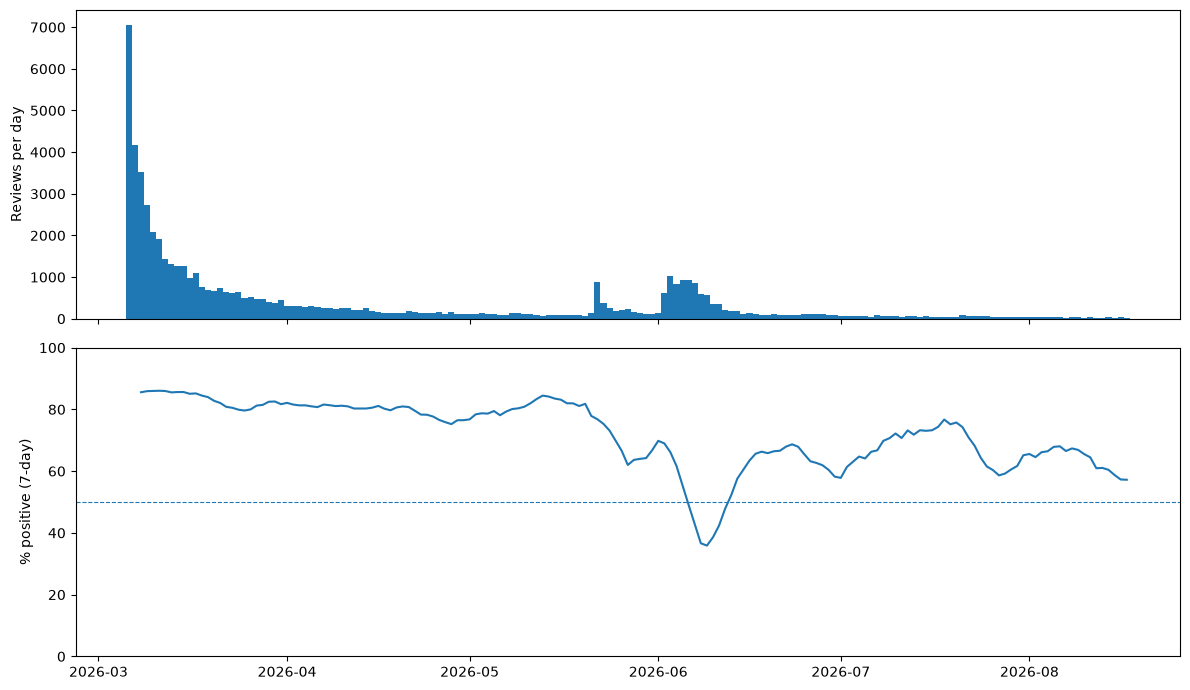

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.bar(daily.date, daily.n_reviews, width=1.0)
ax1.set_ylabel("Reviews per day")

ax2.plot(daily.date, daily.pct_positive_7d)
ax2.axhline(50, linestyle="--", linewidth=0.8)
ax2.set_ylabel("% positive (7-day)")
ax2.set_ylim(0, 100)

plt.tight_layout()

In [12]:
df = pd.read_parquet("../data/processed/reviews_clean.parquet")
print(df.shape)
print(df.columns.tolist())

(59489, 19)
['recommendationid', 'created_at', 'days_since_launch', 'voted_up', 'review', 'review_length', 'language', 'is_english', 'playtime_at_review_hours', 'playtime_forever_hours', 'author_num_games_owned', 'author_num_reviews', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access']


In [13]:
mentions_destiny = df.review.str.contains(
    r"destiny|d2\b|final shape|bungie killed", case=False, regex=True
)

window = df[(df.days_since_launch > 75) & (df.days_since_launch < 110)]
w_mentions = window.review.str.contains(r"destiny|d2\b|final shape", case=False)

print(f"share of window reviews mentioning Destiny: {w_mentions.mean()*100:.1f}%")
print(f"sentiment, all:              {window.voted_up.mean()*100:.1f}%")
print(f"sentiment, Destiny-mentions: {window[w_mentions].voted_up.mean()*100:.1f}%")
print(f"sentiment, no Destiny:       {window[~w_mentions].voted_up.mean()*100:.1f}%")
print(f"median playtime, Destiny-mentions: {window[w_mentions].playtime_at_review_hours.median():.1f}h")
print(f"median playtime, no Destiny:       {window[~w_mentions].playtime_at_review_hours.median():.1f}h")

share of window reviews mentioning Destiny: 16.9%
sentiment, all:              50.2%
sentiment, Destiny-mentions: 36.9%
sentiment, no Destiny:       53.0%
median playtime, Destiny-mentions: 9.9h
median playtime, no Destiny:       9.8h


In [14]:
neg = window[~w_mentions & ~window.voted_up & window.is_english]
print(f"n = {len(neg):,}")

for term in ["price", "cost", "shop", "store", "microtransaction", "mtx", "p2w",
             "season 2", "grind", "content", "bug", "cheat", "match", "queue",
             "balance", "nerf", "dead game", "player count"]:
    share = neg.review.str.contains(term, case=False).mean() * 100
    print(f"{term:18s} {share:5.1f}%")

n = 2,857
price                1.9%
cost                 1.1%
shop                 0.6%
store                0.8%
microtransaction     0.5%
mtx                  0.1%
p2w                  0.0%
season 2             1.8%
grind                1.8%
content              1.9%
bug                  1.7%
cheat                2.4%
match                8.4%
queue                2.0%
balance              2.2%
nerf                 0.8%
dead game            0.4%
player count         0.8%


In [16]:
for r in neg.review.sample(15, random_state=42):
    print("---")
    print(r[:400])

---
i run around in danger, and everything's pretty much stronger than me . I manage to get some loot after a few playthroughs, but then it said the season ended and they took what little I had. 
It makes it hard to find a reason to play if i lose my loot when I die and I lose my whole inventory every quarter.
makes me feel the same hopelessness as an adult in the workforce

this games not like Arc Ra
---
do not buy this game if you plan on playing solo, possibly the worst experience you could ever have
---
Marathon is an absolute nightmare for new players to get into and while it does have glimmers of that same gunplay and feel you might be used to from bungie. It doesn't save the experience, ultimately the game feels barebones, initially confusing and it's art style while it might have it's moments in terms of it's 2D graphics, i personally find in it's actual gameplay to be ugly, loud and counteri
---
steaming pile of ♥♥♥♥♥♥♥ like the rest of extraction shooters shut them all down
-

In [20]:
themes = {
    "wipe/loss":    r"wipe|lost my|lose my|inventory|season end|took my|reset",
    "solo/new":     r"\bsolo\b|new player|nightmare to|learning curve|friend quit|didn'?t last",
    "genre":        r"arc raider|extraction shooter|tarkov|another extraction",
    "monetization": r"cosmetic|skin|store|\$|price|paid|worth \$",
    "ttk/combat":   r"\bttk\b|time to kill|one shot|sniper|melee|knife",
}

for name, pat in themes.items():
    print(f"{name:14s} {neg.review.str.contains(pat, case=False).mean()*100:5.1f}%")

wipe/loss        4.3%
solo/new         7.9%
genre           17.7%
monetization     7.1%
ttk/combat       3.2%


In [18]:
g = neg[neg.review.str.contains(r"arc raider|extraction shooter|tarkov", case=False)]
for r in g.review.sample(10, random_state=3):
    print("---")
    print(r[:300])

---
Just play Arc Raiders, this one ain't it
---
Great style, battle passes don't get removed after. Why did this have to be an extraction shooter?

I don't trust bungie or sony to support this long term. Wait for free to play.
---
this game felt like i was just walking around doing nothing, boring chore simulator, i dont know why bungie made this game extraction shooters were a fad that were done infinitely better before marathon even released. if you are unemployed and love to waste your time playing extraction shooters, you
---
boring asf, just play tarkov instead
---
tried it twice now (during the free events) and both times just kind of meh. if you like extraction shooters you'll probably enjoy it if you don't like them then you probably won't like the game. though gun play feels really good so I can give the game that!
---
Arc Raiders eif besser
---
Game design is beautiful.
But that's all it has going for me.
Just another extraction shooter carbon copy.

But it is pretty. But th

In [19]:
solo_new = neg.review.str.contains(themes["solo/new"], case=False)
print(f"median playtime, solo/new complaints: {neg[solo_new].playtime_at_review_hours.median():.1f}h")
print(f"median playtime, other negatives:     {neg[~solo_new].playtime_at_review_hours.median():.1f}h")

median playtime, solo/new complaints: 5.8h
median playtime, other negatives:     1.8h


In [21]:
neg_all = df[~df.voted_up & df.is_english]
pos_all = df[df.voted_up & df.is_english]

print(f"negative reviews under 2h: {(neg_all.playtime_at_review_hours < 2).mean()*100:.1f}%")
print(f"positive reviews under 2h: {(pos_all.playtime_at_review_hours < 2).mean()*100:.1f}%")
print(f"median negative: {neg_all.playtime_at_review_hours.median():.1f}h")
print(f"median positive: {pos_all.playtime_at_review_hours.median():.1f}h")

negative reviews under 2h: 31.3%
positive reviews under 2h: 2.8%
median negative: 6.8h
median positive: 21.6h


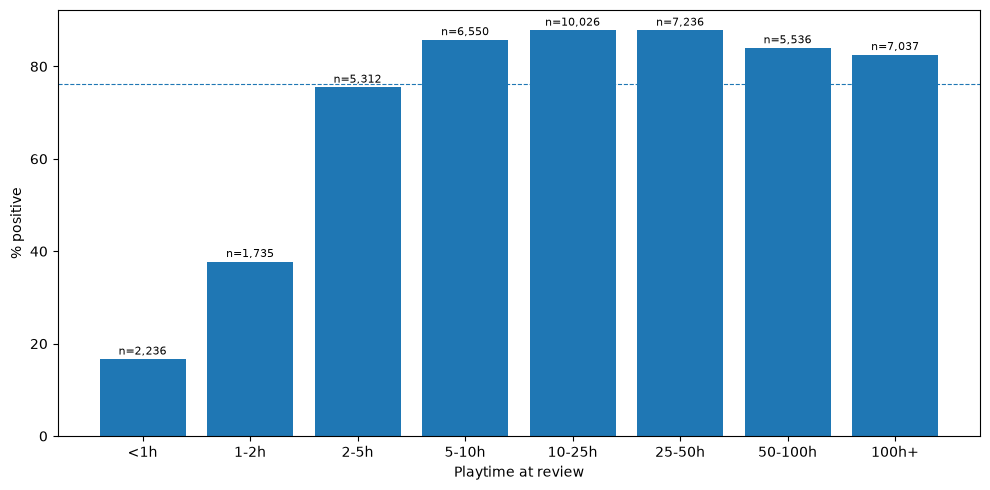

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = [0, 1, 2, 5, 10, 25, 50, 100, 10000]
labels = ["<1h", "1-2h", "2-5h", "5-10h", "10-25h", "25-50h", "50-100h", "100h+"]

pt = pd.cut(df[df.is_english].playtime_at_review_hours, bins=bins, labels=labels, right=False)
rate = df[df.is_english].groupby(pt, observed=True).voted_up.mean() * 100
counts = df[df.is_english].groupby(pt, observed=True).size()

ax.bar(rate.index.astype(str), rate.values)
ax.axhline(76.3, linestyle="--", linewidth=0.8)
ax.set_ylabel("% positive")
ax.set_xlabel("Playtime at review")
for i, (r, n) in enumerate(zip(rate.values, counts.values)):
    ax.text(i, r + 1, f"n={n:,}", ha="center", fontsize=8)
plt.tight_layout()

In [25]:
from pathlib import Path
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("../reports/figures/reviews_over_time.png", dpi=150, bbox_inches="tight")
